In [1]:
!unzip "UCI HAR Dataset.zip"

Archive:  UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
   creating: UCI HAR Dataset/test/
   creating: UCI HAR Dataset/test/Inertial Signals/
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
   creating: __MACOSX/UCI HAR Dataset/test/
   creating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating: UCI HAR

In [2]:
!find /content -maxdepth 3 -type d

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.09.16
/content/UCI HAR Dataset
/content/UCI HAR Dataset/test
/content/UCI HAR Dataset/test/Inertial Signals
/content/UCI HAR Dataset/train
/content/UCI HAR Dataset/train/Inertial Signals
/content/__MACOSX
/content/__MACOSX/UCI HAR Dataset
/content/__MACOSX/UCI HAR Dataset/test
/content/__MACOSX/UCI HAR Dataset/train
/content/sample_data


In [3]:
!find /content -maxdepth 4 -type f | head -30

/content/.config/default_configs.db
/content/.config/active_config
/content/.config/gce
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/.last_update_check.json
/content/.config/logs/2026.09.16/13.26.04.283691.log
/content/.config/logs/2026.09.16/13.25.37.877256.log
/content/.config/logs/2026.09.16/13.26.29.139725.log
/content/.config/logs/2026.09.16/13.26.15.129583.log
/content/.config/logs/2026.09.16/13.26.17.091876.log
/content/.config/logs/2026.09.16/13.26.30.459687.log
/content/.config/config_sentinel
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/UCI HAR Dataset/test/subject_test.txt
/content/UCI HAR Dataset/test/Inertial Signals/total_acc_z_test.txt
/content/UCI HAR Dataset/test/Inertial Signals/total_acc_x_test.txt
/content/UCI HAR Dataset/test/Inertial Signals/body_gyro_y_test.txt
/content/UCI HAR Dataset/test/Inertial Signals/body_gyro_z

In [4]:
import numpy as np
import pandas as pd

DATA_PATH = "/content/UCI HAR Dataset"

# Load X
X_train = np.loadtxt(
    f"{DATA_PATH}/train/X_train.txt"
)

X_test = np.loadtxt(
    f"{DATA_PATH}/test/X_test.txt"
)

# Load y
y_train = np.loadtxt(
    f"{DATA_PATH}/train/y_train.txt"
).astype(int) - 1

y_test = np.loadtxt(
    f"{DATA_PATH}/test/y_test.txt"
).astype(int) - 1

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7352, 561)
X_test : (2947, 561)
y_train: (7352,)
y_test : (2947,)


In [5]:
signals = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

In [6]:
train_signals = []

for signal in signals:

    file_path = (
        f"{DATA_PATH}/train/Inertial Signals/"
        f"{signal}_train.txt"
    )

    data = np.loadtxt(file_path)

    train_signals.append(data)

X_train_seq = np.stack(
    train_signals,
    axis=2
)

print("X_train_seq:", X_train_seq.shape)

X_train_seq: (7352, 128, 9)


In [7]:
test_signals = []

for signal in signals:

    file_path = (
        f"{DATA_PATH}/test/Inertial Signals/"
        f"{signal}_test.txt"
    )

    data = np.loadtxt(file_path)

    test_signals.append(data)

X_test_seq = np.stack(
    test_signals,
    axis=2
)

print("X_test_seq:", X_test_seq.shape)

X_test_seq: (2947, 128, 9)


In [8]:
print("=" * 50)
print("HAR DATASET READY")
print("=" * 50)

print("Training data :", X_train_seq.shape)
print("Testing data  :", X_test_seq.shape)
print("Training labels:", y_train.shape)
print("Testing labels :", y_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Sequence length :", X_train_seq.shape[1])
print("Features        :", X_train_seq.shape[2])

HAR DATASET READY
Training data : (7352, 128, 9)
Testing data  : (2947, 128, 9)
Training labels: (7352,)
Testing labels : (2947,)
Number of classes: 6
Sequence length : 128
Features        : 9


In [9]:
import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

from sklearn.metrics import accuracy_score, f1_score

In [10]:
def build_rnn(units):

    model = Sequential([

        SimpleRNN(
            units,
            activation="tanh",
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        Dense(
            6,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
results_units = []

for units in [16, 32, 64]:

    print("\n" + "=" * 60)
    print(f"RNN WITH {units} UNITS")
    print("=" * 60)

    model = build_rnn(units)

    start_time = time.time()

    model.fit(
        X_train_seq,
        y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    training_time = time.time() - start_time

    # Prediction
    y_pred_prob = model.predict(
        X_test_seq,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    parameters = model.count_params()

    results_units.append({
        "Units": units,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Parameter Count": parameters,
        "Training Time (sec)": training_time
    })

    print(f"\nAccuracy        : {accuracy:.4f}")
    print(f"F1-Score        : {f1:.4f}")
    print(f"Parameter Count : {parameters:,}")
    print(f"Training Time   : {training_time:.2f} sec")


RNN WITH 16 UNITS


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.4820 - loss: 1.3898 - val_accuracy: 0.5082 - val_loss: 1.2150
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.5408 - loss: 1.1459 - val_accuracy: 0.5611 - val_loss: 1.0766
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5346 - loss: 1.1484 - val_accuracy: 0.3981 - val_loss: 1.6621
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5003 - loss: 1.1126 - val_accuracy: 0.5136 - val_loss: 1.0052
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5848 - loss: 1.0332 - val_accuracy: 0.5476 - val_loss: 0.9755
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5865 - loss: 1.0096 - val_accuracy: 0.5340 - val_loss: 0.9671
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5662 - loss: 1.0295 - val_accuracy: 0.4783 - val_loss: 1.0306
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5819 - loss: 1.0000 - val_accu

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4539 - loss: 1.3784 - val_accuracy: 0.5380 - val_loss: 1.0888
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5695 - loss: 1.0408 - val_accuracy: 0.5679 - val_loss: 0.9130
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6112 - loss: 0.9100 - val_accuracy: 0.5530 - val_loss: 0.8041
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6038 - loss: 0.9218 - val_accuracy: 0.6562 - val_loss: 0.6914
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6590 - loss: 0.7493 - val_accuracy: 0.5842 - val_loss: 0.7617
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6709 - loss: 0.7254 - val_accuracy: 0.6345 - val_loss: 0.6875
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6756 - loss: 0.7393 - val_accuracy: 0.6508 - val_loss: 0.6906
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6859 - loss: 0.7047 - val_accuracy: 0.673

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.4882 - loss: 1.2033 - val_accuracy: 0.5476 - val_loss: 1.0623
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6078 - loss: 0.9804 - val_accuracy: 0.5571 - val_loss: 0.8611
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6832 - loss: 0.7464 - val_accuracy: 0.6671 - val_loss: 0.7023
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5689 - loss: 1.1098 - val_accuracy: 0.5747 - val_loss: 0.9614
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6511 - loss: 0.8623 - val_accuracy: 0.6440 - val_loss: 0.7315
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6991 - loss: 0.6955 - val_accuracy: 0.6155 - val_loss: 0.6946
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6765 - loss: 0.7719 - val_accuracy: 0.6807 - val_loss: 0.6907
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7201 - loss: 0.6533 - val_accuracy: 0.684

In [12]:
results_df = pd.DataFrame(results_units)

display(results_df)

,Units,Accuracy,F1-Score,Parameter Count,Training Time (sec)
0,16,0.545300,0.496547,518,31.566549
1,32,0.678996,0.658826,1542,28.996499
2,64,0.442823,0.420923,5126,31.389376


In [13]:
from tensorflow.keras.layers import LSTM, GRU

def build_lstm(units=32):

    model = Sequential([
        LSTM(
            units,
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        Dense(
            6,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
def build_gru(units=32):

    model = Sequential([
        GRU(
            units,
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        Dense(
            6,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [15]:
results_gru_lstm = []

# =========================
# LSTM
# =========================

print("\n" + "=" * 60)
print("LSTM - 32 UNITS")
print("=" * 60)

lstm_model = build_lstm(32)

start_time = time.time()

lstm_model.fit(
    X_train_seq,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

lstm_time = time.time() - start_time

lstm_prob = lstm_model.predict(
    X_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test,
    lstm_pred
)

lstm_f1 = f1_score(
    y_test,
    lstm_pred,
    average="macro"
)

results_gru_lstm.append({
    "Model": "LSTM",
    "Units": 32,
    "Accuracy": lstm_accuracy,
    "F1-Score": lstm_f1,
    "Parameter Count": lstm_model.count_params(),
    "Training Time (sec)": lstm_time
})


# =========================
# GRU
# =========================

print("\n" + "=" * 60)
print("GRU - 32 UNITS")
print("=" * 60)

gru_model = build_gru(32)

start_time = time.time()

gru_model.fit(
    X_train_seq,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

gru_time = time.time() - start_time

gru_prob = gru_model.predict(
    X_test_seq,
    verbose=0
)

gru_pred = np.argmax(
    gru_prob,
    axis=1
)

gru_accuracy = accuracy_score(
    y_test,
    gru_pred
)

gru_f1 = f1_score(
    y_test,
    gru_pred,
    average="macro"
)

results_gru_lstm.append({
    "Model": "GRU",
    "Units": 32,
    "Accuracy": gru_accuracy,
    "F1-Score": gru_f1,
    "Parameter Count": gru_model.count_params(),
    "Training Time (sec)": gru_time
})


LSTM - 32 UNITS
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.4308 - loss: 1.3611 - val_accuracy: 0.5312 - val_loss: 1.0660
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6499 - loss: 0.9031 - val_accuracy: 0.6671 - val_loss: 0.7461
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7096 - loss: 0.7266 - val_accuracy: 0.6834 - val_loss: 0.6514
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7440 - loss: 0.6087 - val_accuracy: 0.8125 - val_loss: 0.5706
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8124 - loss: 0.5233 - val_accuracy: 0.8274 - val_loss: 0.4609
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8490 - loss: 0.4636 - val_accuracy: 0.8451 - val_loss: 0.4224
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8733 - loss: 0.3974 - val_accuracy: 0.8818 - val_loss: 0.3755
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.8803 - loss: 0.3598 - val_accuracy: 0.868

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.4160 - loss: 1.4548 - val_accuracy: 0.4674 - val_loss: 1.1888
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.5464 - loss: 1.0868 - val_accuracy: 0.4769 - val_loss: 1.0111
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6180 - loss: 0.9202 - val_accuracy: 0.6889 - val_loss: 0.7050
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.6873 - loss: 0.7028 - val_accuracy: 0.7649 - val_loss: 0.6021
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.7453 - loss: 0.6163 - val_accuracy: 0.7812 - val_loss: 0.6216
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.7768 - loss: 0.6207 - val_accuracy: 0.8641 - val_loss: 0.4994
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8414 - loss: 0.4601 - val_accuracy: 0.9130 - val_loss: 0.3830
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8561 - loss: 0.4004 - val_accuracy: 0.

In [16]:
results_gru_lstm = []

# =========================
# LSTM
# =========================

print("\n" + "=" * 60)
print("LSTM - 32 UNITS")
print("=" * 60)

lstm_model = build_lstm(32)

start_time = time.time()

lstm_model.fit(
    X_train_seq,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

lstm_time = time.time() - start_time

lstm_prob = lstm_model.predict(
    X_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test,
    lstm_pred
)

lstm_f1 = f1_score(
    y_test,
    lstm_pred,
    average="macro"
)

results_gru_lstm.append({
    "Model": "LSTM",
    "Units": 32,
    "Accuracy": lstm_accuracy,
    "F1-Score": lstm_f1,
    "Parameter Count": lstm_model.count_params(),
    "Training Time (sec)": lstm_time
})


# =========================
# GRU
# =========================

print("\n" + "=" * 60)
print("GRU - 32 UNITS")
print("=" * 60)

gru_model = build_gru(32)

start_time = time.time()

gru_model.fit(
    X_train_seq,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

gru_time = time.time() - start_time

gru_prob = gru_model.predict(
    X_test_seq,
    verbose=0
)

gru_pred = np.argmax(
    gru_prob,
    axis=1
)

gru_accuracy = accuracy_score(
    y_test,
    gru_pred
)

gru_f1 = f1_score(
    y_test,
    gru_pred,
    average="macro"
)

results_gru_lstm.append({
    "Model": "GRU",
    "Units": 32,
    "Accuracy": gru_accuracy,
    "F1-Score": gru_f1,
    "Parameter Count": gru_model.count_params(),
    "Training Time (sec)": gru_time
})


LSTM - 32 UNITS
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4188 - loss: 1.4083 - val_accuracy: 0.4986 - val_loss: 1.1973
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.5218 - loss: 1.1196 - val_accuracy: 0.5571 - val_loss: 1.0047
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6188 - loss: 0.8536 - val_accuracy: 0.6535 - val_loss: 0.7192
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6638 - loss: 0.7468 - val_accuracy: 0.6644 - val_loss: 0.6915
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6442 - loss: 0.9397 - val_accuracy: 0.5516 - val_loss: 1.2442
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6412 - loss: 0.9384 - val_accuracy: 0.5666 - val_loss: 0.9275
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.6649 - loss: 0.8466 - val_accuracy: 0.6658 - val_loss: 0.8043
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.7121 - loss: 0.7385 - val_accuracy: 0.669

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.4371 - loss: 1.4634 - val_accuracy: 0.5014 - val_loss: 1.1545
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5493 - loss: 1.0926 - val_accuracy: 0.5747 - val_loss: 0.9391
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.6307 - loss: 0.8938 - val_accuracy: 0.6630 - val_loss: 0.6829
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7096 - loss: 0.6745 - val_accuracy: 0.6916 - val_loss: 0.6517
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7693 - loss: 0.5978 - val_accuracy: 0.7418 - val_loss: 0.6084
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8271 - loss: 0.4848 - val_accuracy: 0.7785 - val_loss: 0.4773
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.8505 - loss: 0.3784 - val_accuracy: 0.7962 - val_loss: 0.4403
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8850 - loss: 0.3197 - val_accuracy: 0.84

In [17]:
gru_lstm_df = pd.DataFrame(results_gru_lstm)

display(gru_lstm_df)

,Model,Units,Accuracy,F1-Score,Parameter Count,Training Time (sec)
0,LSTM,32,0.686461,0.679601,5574,50.621639
1,GRU,32,0.845945,0.842012,4326,79.120647


In [18]:
# ============================================================
# EXERCISE 3
# ADD A SECOND RECURRENT LAYER
# ============================================================

import numpy as np
import pandas as pd
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from sklearn.metrics import accuracy_score, f1_score


# ------------------------------------------------------------
# 1. Number of classes
# ------------------------------------------------------------

NUM_CLASSES = len(np.unique(y_train))

print("Number of classes:", NUM_CLASSES)
print("Training shape:", X_train_seq.shape)
print("Testing shape :", X_test_seq.shape)


# ------------------------------------------------------------
# 2. Single-Layer LSTM
# ------------------------------------------------------------

def build_single_lstm():

    model = Sequential([

        LSTM(
            32,
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 3. Two-Layer LSTM
# ------------------------------------------------------------

def build_two_layer_lstm():

    model = Sequential([

        # First LSTM must return the sequence
        LSTM(
            32,
            return_sequences=True,
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        # Second LSTM
        LSTM(32),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def train_and_evaluate(model, model_name):

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    start_time = time.time()

    model.fit(
        X_train_seq,
        y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    training_time = time.time() - start_time

    # Prediction
    probabilities = model.predict(
        X_test_seq,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    # Metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    parameters = model.count_params()

    print("\nResults:")
    print("Accuracy        :", round(accuracy, 4))
    print("F1-Score        :", round(f1, 4))
    print("Parameter Count :", f"{parameters:,}")
    print("Training Time   :", round(training_time, 2), "seconds")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Parameter Count": parameters,
        "Training Time (sec)": training_time
    }


# ------------------------------------------------------------
# 5. Train Single-Layer LSTM
# ------------------------------------------------------------

single_lstm = build_single_lstm()

single_result = train_and_evaluate(
    single_lstm,
    "Single-Layer LSTM"
)


# ------------------------------------------------------------
# 6. Train Two-Layer LSTM
# ------------------------------------------------------------

two_lstm = build_two_layer_lstm()

two_result = train_and_evaluate(
    two_lstm,
    "Two-Layer LSTM"
)


# ------------------------------------------------------------
# 7. Comparison table
# ------------------------------------------------------------

exercise3_results = pd.DataFrame([
    single_result,
    two_result
])

print("\n" + "=" * 60)
print("EXERCISE 3 - FINAL COMPARISON")
print("=" * 60)

display(exercise3_results)

Number of classes: 6
Training shape: (7352, 128, 9)
Testing shape : (2947, 128, 9)

Single-Layer LSTM


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.4568 - loss: 1.3678 - val_accuracy: 0.5204 - val_loss: 1.0721
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5738 - loss: 1.0507 - val_accuracy: 0.5408 - val_loss: 1.0597
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6988 - loss: 0.7820 - val_accuracy: 0.6793 - val_loss: 0.6873
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7857 - loss: 0.5653 - val_accuracy: 0.8016 - val_loss: 0.5217
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.8263 - loss: 0.4769 - val_accuracy: 0.6372 - val_loss: 1.0154
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6341 - loss: 0.9391 - val_accuracy: 0.6739 - val_loss: 0.6639
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7542 - loss: 0.6194 - val_accuracy: 0.6739 - val_loss: 0.6183
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.7780 - loss: 0.5931 - val_ac

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.5062 - loss: 1.2190 - val_accuracy: 0.6386 - val_loss: 0.8909
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.6706 - loss: 0.7757 - val_accuracy: 0.6916 - val_loss: 0.7024
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.7502 - loss: 0.6086 - val_accuracy: 0.7432 - val_loss: 0.5544
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8117 - loss: 0.4952 - val_accuracy: 0.8111 - val_loss: 0.4260
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8560 - loss: 0.4114 - val_accuracy: 0.8424 - val_loss: 0.3519
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8989 - loss: 0.3078 - val_accuracy: 0.8342 - val_loss: 0.5714
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9187 - loss: 0.2609 - val_accuracy: 0.8356 - val_loss: 0.4042
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9327 - loss: 0.2112 - val_accuracy:

,Model,Accuracy,F1-Score,Parameter Count,Training Time (sec)
0,Single-Layer LSTM,0.737699,0.727441,5574,63.206023
1,Two-Layer LSTM,0.873431,0.873479,13894,101.495646


In [19]:
# ============================================================
# EXERCISE 4
# BIDIRECTIONAL LSTM vs UNIDIRECTIONAL LSTM
# ============================================================

import numpy as np
import pandas as pd
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional

from sklearn.metrics import accuracy_score, f1_score


# ------------------------------------------------------------
# 1. Number of classes
# ------------------------------------------------------------

NUM_CLASSES = len(np.unique(y_train))

print("Number of classes:", NUM_CLASSES)
print("Training shape:", X_train_seq.shape)
print("Testing shape :", X_test_seq.shape)


# ------------------------------------------------------------
# 2. Unidirectional LSTM
# ------------------------------------------------------------

def build_unidirectional_lstm():

    model = Sequential([

        LSTM(
            32,
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 3. Bidirectional LSTM
# ------------------------------------------------------------

def build_bidirectional_lstm():

    model = Sequential([

        Bidirectional(
            LSTM(32),
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def train_and_evaluate(model, model_name):

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    start_time = time.time()

    model.fit(
        X_train_seq,
        y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    training_time = time.time() - start_time

    # Prediction
    probabilities = model.predict(
        X_test_seq,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    # Metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    parameters = model.count_params()

    print("\nResults:")
    print("Accuracy        :", round(accuracy, 4))
    print("F1-Score        :", round(f1, 4))
    print("Parameter Count :", f"{parameters:,}")
    print("Training Time   :", round(training_time, 2), "seconds")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Parameter Count": parameters,
        "Training Time (sec)": training_time
    }


# ------------------------------------------------------------
# 5. Train Unidirectional LSTM
# ------------------------------------------------------------

uni_lstm = build_unidirectional_lstm()

uni_result = train_and_evaluate(
    uni_lstm,
    "Unidirectional LSTM"
)


# ------------------------------------------------------------
# 6. Train Bidirectional LSTM
# ------------------------------------------------------------

bi_lstm = build_bidirectional_lstm()

bi_result = train_and_evaluate(
    bi_lstm,
    "Bidirectional LSTM"
)


# ------------------------------------------------------------
# 7. Comparison table
# ------------------------------------------------------------

exercise4_results = pd.DataFrame([
    uni_result,
    bi_result
])

print("\n" + "=" * 60)
print("EXERCISE 4 - FINAL COMPARISON")
print("=" * 60)

display(exercise4_results)

Number of classes: 6
Training shape: (7352, 128, 9)
Testing shape : (2947, 128, 9)

Unidirectional LSTM
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4361 - loss: 1.4219 - val_accuracy: 0.5258 - val_loss: 1.1824
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5540 - loss: 1.0958 - val_accuracy: 0.5217 - val_loss: 1.0443
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6596 - loss: 0.8677 - val_accuracy: 0.7065 - val_loss: 0.7448
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7335 - loss: 0.6970 - val_accuracy: 0.7337 - val_loss: 0.6410
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.7814 - loss: 0.5801 - val_accuracy: 0.6590 - val_loss: 0.6177
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8248 - loss: 0.4940 - val_accuracy: 0.8125 - val_loss: 0.4922
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8797 - loss: 0.3760 - val_accuracy: 0.8234 - val_loss: 0.3928
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8625 - loss: 0.4440 - val_accuracy: 0.841

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5284 - loss: 1.2556 - val_accuracy: 0.5666 - val_loss: 0.9288
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.6954 - loss: 0.8126 - val_accuracy: 0.7745 - val_loss: 0.6179
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.7917 - loss: 0.6126 - val_accuracy: 0.8628 - val_loss: 0.4733
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8543 - loss: 0.4564 - val_accuracy: 0.9117 - val_loss: 0.2800
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8591 - loss: 0.4069 - val_accuracy: 0.8886 - val_loss: 0.4087
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.8950 - loss: 0.3352 - val_accuracy: 0.8872 - val_loss: 0.3017
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9096 - loss: 0.2860 - val_accuracy: 0.8845 - val_loss: 0.2967
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9098 - loss: 0.2776 - val_accuracy: 0.8

,Model,Accuracy,F1-Score,Parameter Count,Training Time (sec)
0,Unidirectional LSTM,0.817781,0.813098,5574,50.239697
1,Bidirectional LSTM,0.873770,0.873092,11142,89.883493


In [20]:
# ============================================================
# EXERCISE 5
# EFFECT OF SEQUENCE LENGTH
# ============================================================

import numpy as np
import pandas as pd
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from sklearn.metrics import accuracy_score, f1_score


# ------------------------------------------------------------
# 1. Sequence lengths to test
# ------------------------------------------------------------

sequence_lengths = [32, 64, 96, 128]

NUM_CLASSES = len(np.unique(y_train))

print("Original sequence length:", X_train_seq.shape[1])
print("Features:", X_train_seq.shape[2])
print("Testing sequence lengths:", sequence_lengths)


# ------------------------------------------------------------
# 2. Results list
# ------------------------------------------------------------

sequence_results = []


# ------------------------------------------------------------
# 3. Run experiment for each sequence length
# ------------------------------------------------------------

for seq_len in sequence_lengths:

    print("\n" + "=" * 60)
    print(f"SEQUENCE LENGTH = {seq_len}")
    print("=" * 60)


    # --------------------------------------------------------
    # Create shorter sequences
    # --------------------------------------------------------

    X_train_current = X_train_seq[:, :seq_len, :]

    X_test_current = X_test_seq[:, :seq_len, :]


    print("Training shape:", X_train_current.shape)
    print("Testing shape :", X_test_current.shape)


    # --------------------------------------------------------
    # Build LSTM
    # --------------------------------------------------------

    model = Sequential([

        LSTM(
            32,
            input_shape=(
                seq_len,
                X_train_seq.shape[2]
            )
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    start_time = time.time()

    model.fit(
        X_train_current,
        y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    probabilities = model.predict(
        X_test_current,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    parameters = model.count_params()


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    sequence_results.append({

        "Sequence Length": seq_len,

        "Accuracy": accuracy,

        "F1-Score": f1,

        "Parameter Count": parameters,

        "Training Time (sec)": training_time
    })


    # --------------------------------------------------------
    # Display current result
    # --------------------------------------------------------

    print("\nResults:")
    print("Sequence Length :", seq_len)
    print("Accuracy        :", round(accuracy, 4))
    print("F1-Score        :", round(f1, 4))
    print("Parameter Count :", f"{parameters:,}")
    print("Training Time   :", round(training_time, 2), "seconds")


# ------------------------------------------------------------
# 4. Final comparison table
# ------------------------------------------------------------

exercise5_results = pd.DataFrame(
    sequence_results
)

print("\n" + "=" * 60)
print("EXERCISE 5 - FINAL COMPARISON")
print("=" * 60)

display(exercise5_results)

Original sequence length: 128
Features: 9
Testing sequence lengths: [32, 64, 96, 128]

SEQUENCE LENGTH = 32
Training shape: (7352, 32, 9)
Testing shape : (2947, 32, 9)
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4339 - loss: 1.3902 - val_accuracy: 0.6250 - val_loss: 0.9441
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7142 - loss: 0.7170 - val_accuracy: 0.7228 - val_loss: 0.6175
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7842 - loss: 0.5465 - val_accuracy: 0.8003 - val_loss: 0.4972
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8330 - loss: 0.4439 - val_accuracy: 0.7989 - val_loss: 0.4377
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8523 - loss: 0.3894 - val_accuracy: 0.8560 - val_loss: 0.3735
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8733 - loss: 0.3434 - val_accuracy: 0.8424 - val_loss: 0.3876
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8705 - loss: 0.3598 - val_accuracy: 0.8546 - val_loss: 0.3624
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9045 - loss: 0.2767 - val_accuracy: 0.872

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4640 - loss: 1.3451 - val_accuracy: 0.5163 - val_loss: 1.0385
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6301 - loss: 0.9203 - val_accuracy: 0.6861 - val_loss: 0.7507
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7267 - loss: 0.7178 - val_accuracy: 0.7351 - val_loss: 0.6444
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7798 - loss: 0.5884 - val_accuracy: 0.7894 - val_loss: 0.5621
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8153 - loss: 0.5175 - val_accuracy: 0.7405 - val_loss: 0.5986
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8368 - loss: 0.4640 - val_accuracy: 0.8193 - val_loss: 0.4879
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8794 - loss: 0.3789 - val_accuracy: 0.8628 - val_loss: 0.3959
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9070 - loss: 0.3046 - val_accuracy: 0.888

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.4445 - loss: 1.4014 - val_accuracy: 0.4484 - val_loss: 1.1319
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.6572 - loss: 0.8854 - val_accuracy: 0.6603 - val_loss: 0.8031
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6836 - loss: 0.7440 - val_accuracy: 0.7378 - val_loss: 0.6707
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7692 - loss: 0.5781 - val_accuracy: 0.6943 - val_loss: 0.5609
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8150 - loss: 0.4997 - val_accuracy: 0.7717 - val_loss: 0.5439
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8514 - loss: 0.4336 - val_accuracy: 0.8859 - val_loss: 0.3447
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8794 - loss: 0.3443 - val_accuracy: 0.8736 - val_loss: 0.3032
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9022 - loss: 0.2882 - val_accuracy: 0.900

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.3860 - loss: 1.4484 - val_accuracy: 0.4810 - val_loss: 1.1790
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5659 - loss: 1.0746 - val_accuracy: 0.5924 - val_loss: 0.9098
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6558 - loss: 0.8722 - val_accuracy: 0.6889 - val_loss: 0.7817
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7113 - loss: 0.7446 - val_accuracy: 0.6807 - val_loss: 0.6668
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7396 - loss: 0.6542 - val_accuracy: 0.6943 - val_loss: 0.6682
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7715 - loss: 0.5856 - val_accuracy: 0.7147 - val_loss: 0.5725
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7745 - loss: 0.5979 - val_accuracy: 0.7418 - val_loss: 0.5872
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8268 - loss: 0.5017 - val_accuracy: 0.794

,Sequence Length,Accuracy,F1-Score,Parameter Count,Training Time (sec)
0,32,0.826603,0.822856,5574,17.409369
1,64,0.854768,0.852249,5574,32.989702
2,96,0.856464,0.854525,5574,43.967156
3,128,0.830336,0.826438,5574,59.584441


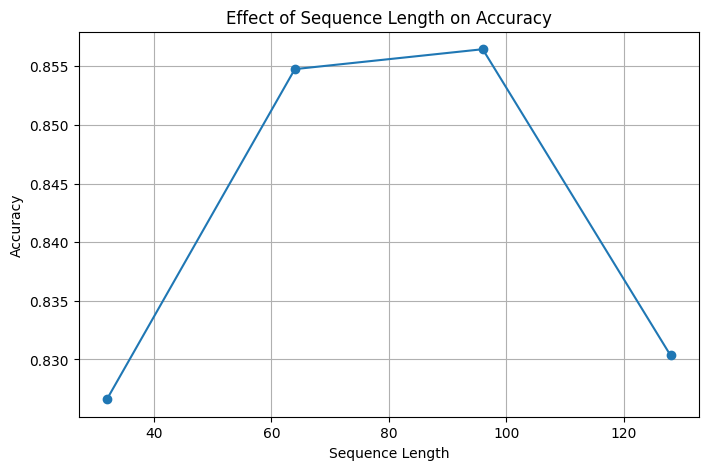

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    exercise5_results["Sequence Length"],
    exercise5_results["Accuracy"],
    marker="o"
)

plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")

plt.title("Effect of Sequence Length on Accuracy")

plt.grid(True)

plt.show()